In [239]:
!pip install pandas numpy matplotlib seaborn tqdm scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [240]:
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from tqdm import tqdm

sns.set_style("whitegrid")

# 1. Load Dataset

In [241]:
# path to dataset
dataset_path = "/Users/ssingodia/Desktop/Catching_Joe/Data/dataset.json"

with open(dataset_path, "r") as f:
    data = json.load(f)

print("Total sessions:", len(data))

Total sessions: 80000


In [242]:
df = pd.DataFrame(data)

df.head()

,browser,os,locale,user_id,gender,location,sites,time,date
0,Firefox,Ubuntu,ru_RU,105,m,USA/Chicago,"[{'site': 'mail.google.com', 'length': 50}, {'...",09:03:00,2017-01-08
1,Firefox,Windows 8,pl-PL,11,m,USA/Chicago,"[{'site': 'meduza.org', 'length': 40}, {'site'...",13:57:00,2016-10-05
2,Chrome,Ubuntu,zh-CN,17,m,Singapore/Singapore,"[{'site': 'facebook.net', 'length': 74}, {'sit...",02:06:00,2017-03-28
3,Chrome,Windows 10,pt-BR,134,f,Australia/Sydney,"[{'site': 'verisign.com', 'length': 111}, {'si...",21:49:00,2017-06-25
4,Firefox,Windows 10,en-SG,92,f,USA/Chicago,"[{'site': 'live.com', 'length': 79}, {'site': ...",00:05:00,2016-02-10


In [243]:
df.info()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   browser   80000 non-null  object
 1   os        80000 non-null  object
 2   locale    80000 non-null  object
 3   user_id   80000 non-null  int64 
 4   gender    80000 non-null  object
 5   location  80000 non-null  object
 6   sites     80000 non-null  object
 7   time      80000 non-null  object
 8   date      80000 non-null  object
dtypes: int64(1), object(8)
memory usage: 5.5+ MB


(80000, 9)

# 2. Dataset Overview

In [244]:
unique_users = df["user_id"].nunique()
print("Unique Users:", unique_users)

Unique Users: 200


In [245]:
joe_sessions = df[df["user_id"] == 0]

print("Joe Sessions:", len(joe_sessions))

Joe Sessions: 400


In [246]:
df["is_joe"] = (df["user_id"] == 0).astype(int)

df["is_joe"].value_counts()

is_joe
0    79600
1      400
Name: count, dtype: int64

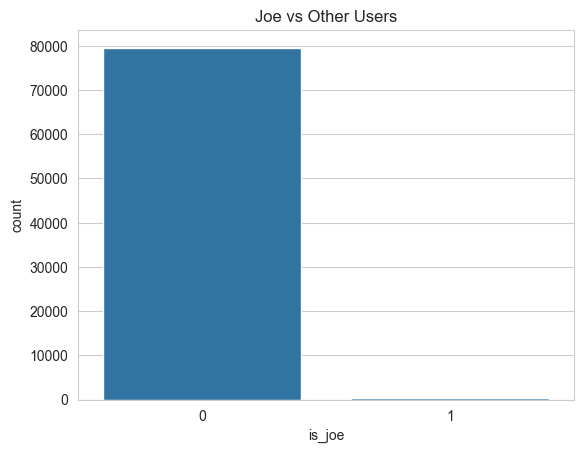

In [247]:
sns.countplot(x="is_joe", data=df)
plt.title("Joe vs Other Users")
plt.show()

# 3. Session Characteristics

In [248]:
def extract_session_features(sites):

    num_sites = len(sites)

    total_time = sum(site["length"] for site in sites)

    avg_time = total_time / num_sites if num_sites > 0 else 0

    return num_sites, total_time, avg_time

In [249]:
df["num_sites"], df["total_time"], df["avg_time"] = zip(
    *df["sites"].apply(extract_session_features)
)

df.head()

,browser,os,locale,user_id,gender,location,sites,time,date,is_joe,num_sites,total_time,avg_time
0,Firefox,Ubuntu,ru_RU,105,m,USA/Chicago,"[{'site': 'mail.google.com', 'length': 50}, {'...",09:03:00,2017-01-08,0,6,481,80.166667
1,Firefox,Windows 8,pl-PL,11,m,USA/Chicago,"[{'site': 'meduza.org', 'length': 40}, {'site'...",13:57:00,2016-10-05,0,9,1076,119.555556
2,Chrome,Ubuntu,zh-CN,17,m,Singapore/Singapore,"[{'site': 'facebook.net', 'length': 74}, {'sit...",02:06:00,2017-03-28,0,7,1280,182.857143
3,Chrome,Windows 10,pt-BR,134,f,Australia/Sydney,"[{'site': 'verisign.com', 'length': 111}, {'si...",21:49:00,2017-06-25,0,9,1323,147.000000
4,Firefox,Windows 10,en-SG,92,f,USA/Chicago,"[{'site': 'live.com', 'length': 79}, {'site': ...",00:05:00,2016-02-10,0,2,224,112.000000


In [250]:
df = df[df["sites"].apply(len) > 0]

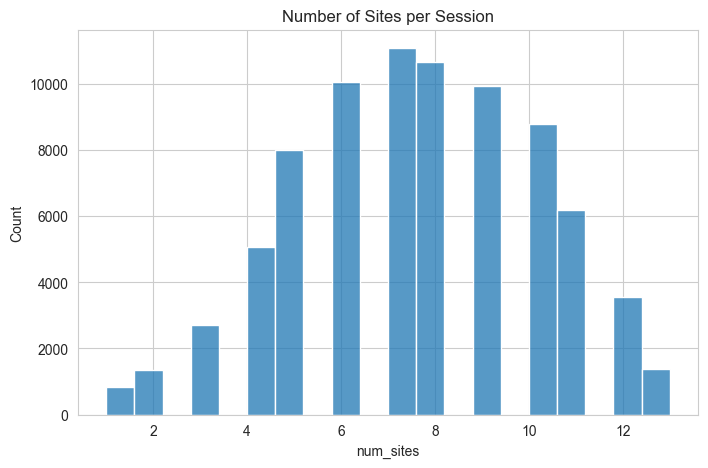

In [251]:
plt.figure(figsize=(8,5))
sns.histplot(df["num_sites"], bins=20)
plt.title("Number of Sites per Session")
plt.show()

In [252]:
df[df["num_sites"]==0].count()

browser       0
os            0
locale        0
user_id       0
gender        0
location      0
sites         0
time          0
date          0
is_joe        0
num_sites     0
total_time    0
avg_time      0
dtype: int64

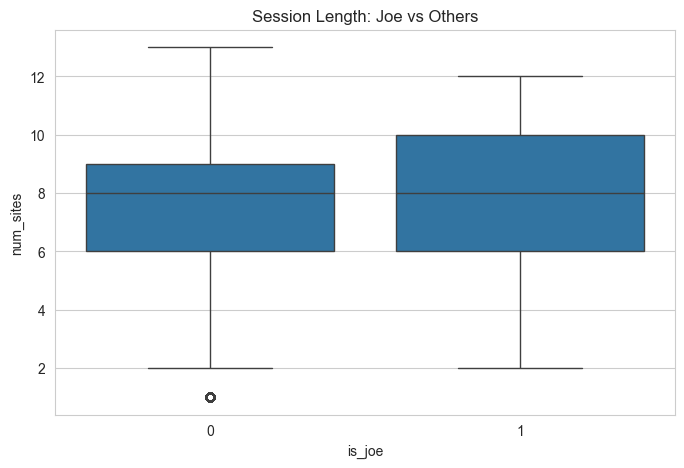

In [253]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_joe", y="num_sites", data=df)
plt.title("Session Length: Joe vs Others")
plt.show()

# 4. Website Frequency Analysis

In [254]:
all_sites = []

for session in df["sites"]:
    for site in session:
        all_sites.append(site["site"])

In [255]:
site_counts = Counter(all_sites)

top_sites = site_counts.most_common(20)

top_sites

[('youtube.com', 28970),
 ('toptal.com', 21929),
 ('slack.com', 21508),
 ('lenta.ru', 18483),
 ('vk.com', 17507),
 ('mail.google.com', 15990),
 ('oracle.com', 10532),
 ('wikimedia.org', 10521),
 ('googleapis.com', 9437),
 ('vimeo.com', 9055),
 ('airbnb.com', 8342),
 ('geotrust.com', 8113),
 ('google.com', 8001),
 ('facebook.com', 7708),
 ('booking.com', 7675),
 ('live.com', 7381),
 ('cedexis.com', 7327),
 ('ggpht.com', 7272),
 ('baidu.com', 7007),
 ('googlevideo.com', 6676)]

In [256]:
top_sites_df = pd.DataFrame(top_sites, columns=["site","count"])

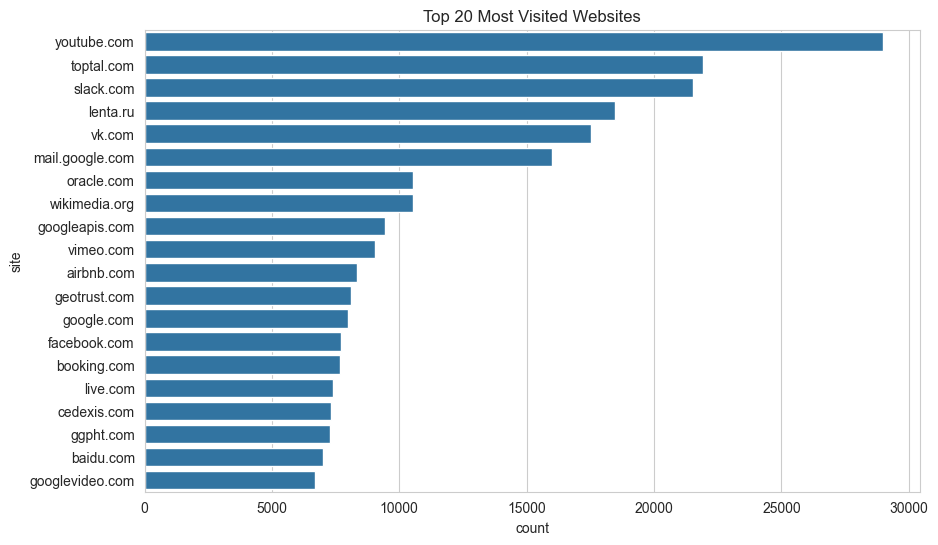

In [257]:
plt.figure(figsize=(10,6))
sns.barplot(x="count", y="site", data=top_sites_df)
plt.title("Top 20 Most Visited Websites")
plt.show()

# 5. Joe vs Others Website Analysis

In [258]:
joe_sites = []

for session in joe_sessions["sites"]:
    for site in session:
        joe_sites.append(site["site"])

In [259]:
joe_site_counts = Counter(joe_sites)

joe_top_sites = joe_site_counts.most_common(15)

joe_top_sites

[('lenta.ru', 361),
 ('toptal.com', 359),
 ('vk.com', 352),
 ('slack.com', 351),
 ('mail.google.com', 348),
 ('youtube.com', 348),
 ('gazzettaobjects.it', 3),
 ('hibapress.com', 2),
 ('dalloz.fr', 2),
 ('free.fr', 2),
 ('escaet.fr', 2),
 ('lyrics.com', 2),
 ('auto-evasion.com', 2),
 ('antonyme.org', 2),
 ('walking-dead.fr', 2)]

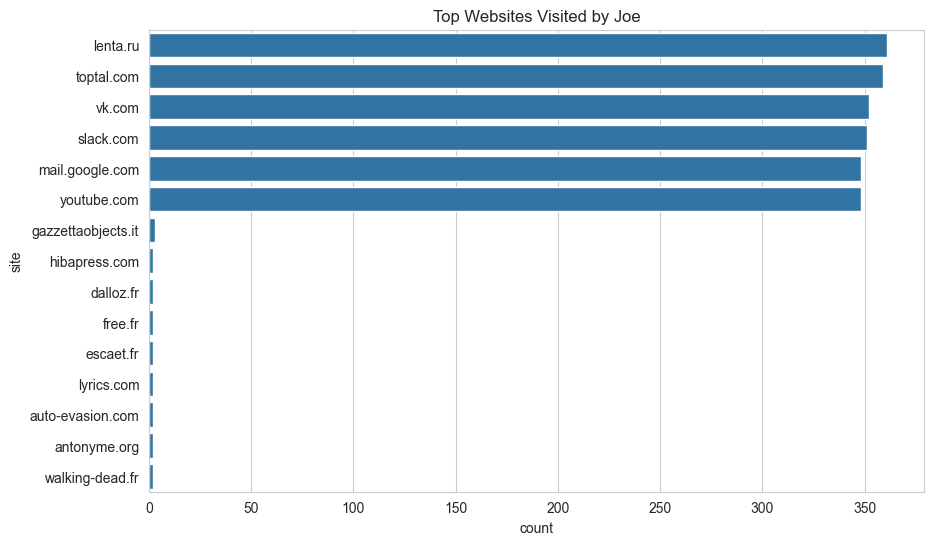

In [260]:
joe_sites_df = pd.DataFrame(joe_top_sites, columns=["site","count"])

plt.figure(figsize=(10,6))
sns.barplot(x="count", y="site", data=joe_sites_df)
plt.title("Top Websites Visited by Joe")
plt.show()

# 6. Website Sequence Patterns

In [261]:
pairs = []

for session in df["sites"]:

    sites = [site["site"] for site in session]

    for i in range(len(sites)-1):

        pairs.append((sites[i], sites[i+1]))

In [262]:
pair_counts = Counter(pairs)

pair_counts.most_common(15)

[(('toptal.com', 'lenta.ru'), 3808),
 (('slack.com', 'lenta.ru'), 2848),
 (('lenta.ru', 'slack.com'), 2742),
 (('mail.google.com', 'youtube.com'), 2640),
 (('toptal.com', 'slack.com'), 2485),
 (('slack.com', 'youtube.com'), 2279),
 (('vk.com', 'mail.google.com'), 2215),
 (('vk.com', 'toptal.com'), 2176),
 (('lenta.ru', 'toptal.com'), 2158),
 (('mail.google.com', 'vk.com'), 2096),
 (('youtube.com', 'youtube.com'), 1963),
 (('mail.google.com', 'toptal.com'), 1892),
 (('youtube.com', 'vk.com'), 1596),
 (('vk.com', 'youtube.com'), 1567),
 (('toptal.com', 'toptal.com'), 1472)]

# 7. Temporal Analysis

In [263]:
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])

df["hour"] = df["datetime"].dt.hour

df["weekday"] = df["datetime"].dt.day_name()

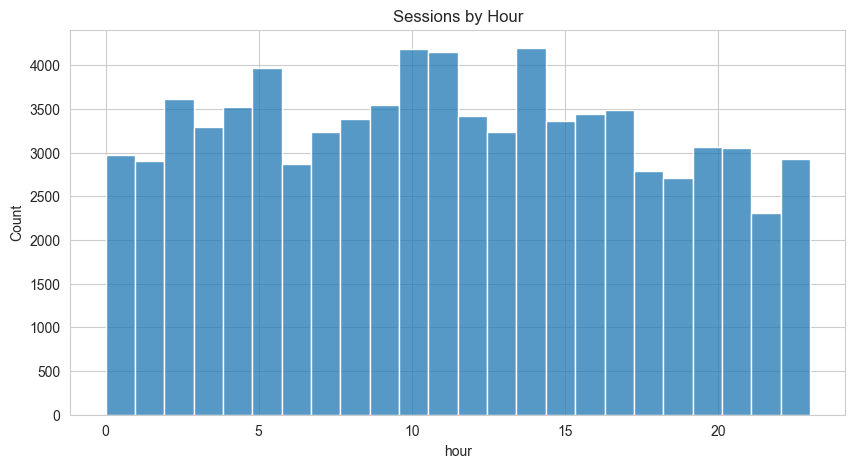

In [264]:
plt.figure(figsize=(10,5))
sns.histplot(df["hour"], bins=24)
plt.title("Sessions by Hour")
plt.show()

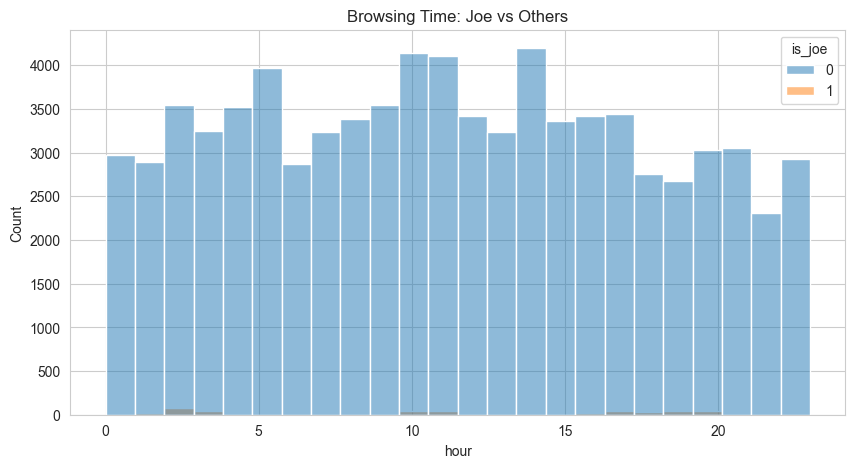

In [265]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="hour", hue="is_joe", bins=24)
plt.title("Browsing Time: Joe vs Others")
plt.show()

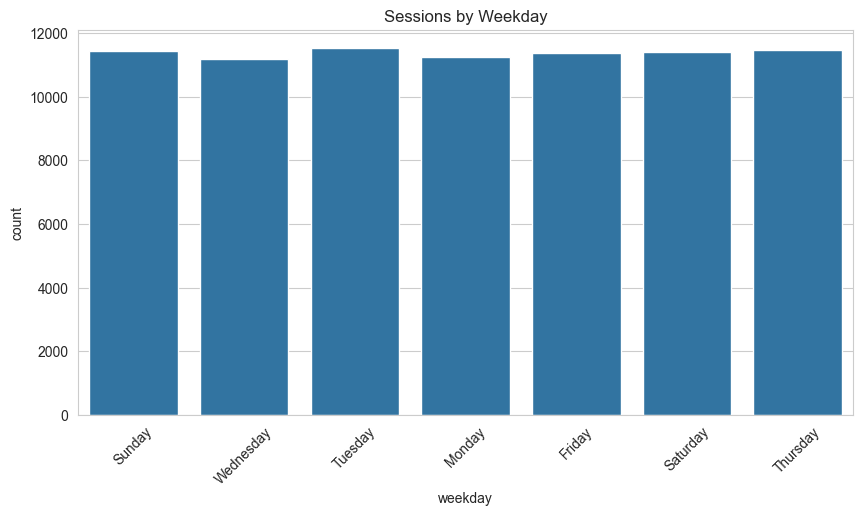

In [266]:
plt.figure(figsize=(10,5))
sns.countplot(x="weekday", data=df)
plt.xticks(rotation=45)
plt.title("Sessions by Weekday")
plt.show()

# 8. Device Analysis

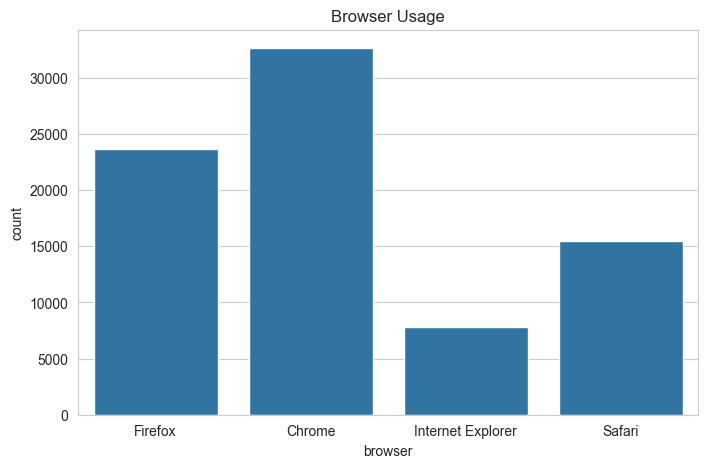

In [267]:
plt.figure(figsize=(8,5))
sns.countplot(x="browser", data=df)
plt.title("Browser Usage")
plt.show()

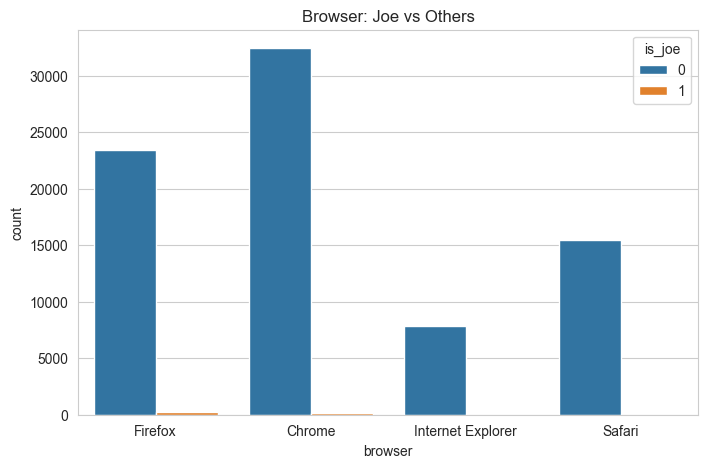

In [268]:
plt.figure(figsize=(8,5))
sns.countplot(x="browser", hue="is_joe", data=df)
plt.title("Browser: Joe vs Others")
plt.show()

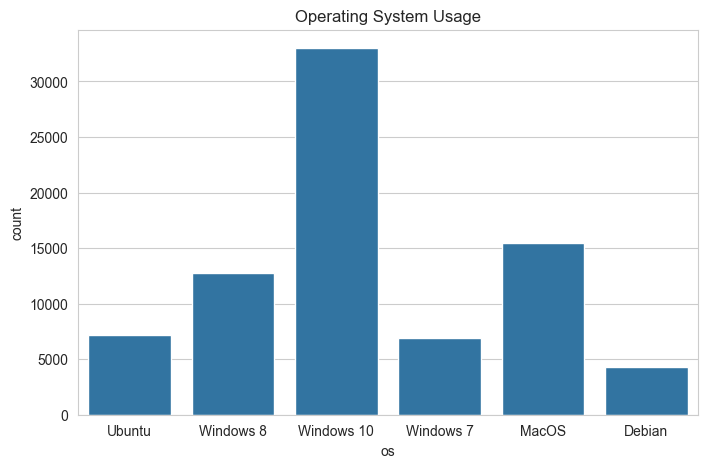

In [269]:
plt.figure(figsize=(8,5))
sns.countplot(x="os", data=df)
plt.title("Operating System Usage")
plt.show()

In [270]:
df["country"] = df["location"].apply(lambda x: x.split("/")[0])

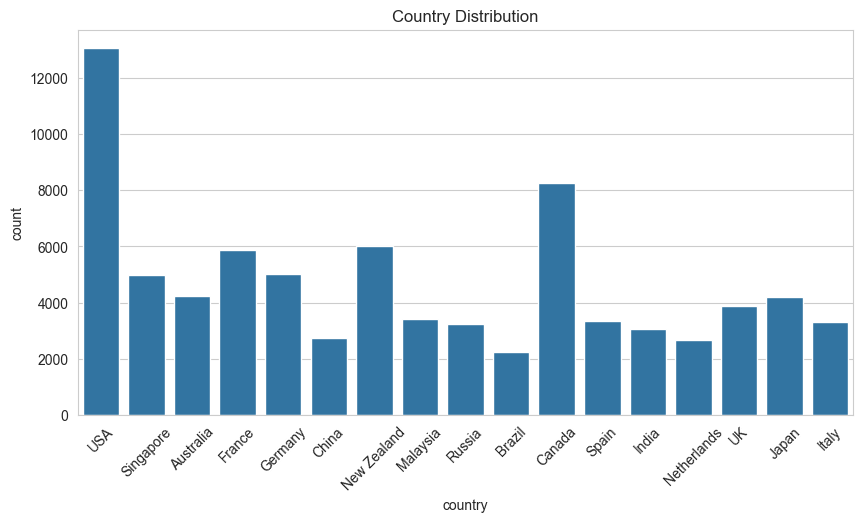

In [271]:
plt.figure(figsize=(10,5))
sns.countplot(x="country", data=df)
plt.xticks(rotation=45)
plt.title("Country Distribution")
plt.show()

## Phase 3

# Feature Engg.

In [272]:
def extract_site_names(site_list):
    
    sites = []
    
    for s in site_list:
        sites.append(s["site"])
        
    return " ".join(sites)

In [273]:
df["site_sequence"] = df["sites"].apply(extract_site_names)

df["site_sequence"].head()

0    mail.google.com toptal.com slack.com lenta.ru ...
1    meduza.org disqus.com youtube.com wikipedia.or...
2    facebook.net live.com youtube.com baidu.com di...
3    verisign.com booking.com openclassrooms.com sl...
4                              live.com livraddict.com
Name: site_sequence, dtype: object

# 3. Website Frequency Features

In [274]:
from sklearn.feature_extraction.text import CountVectorizer

In [275]:
vectorizer = CountVectorizer()

X_sites = vectorizer.fit_transform(df["site_sequence"])

In [276]:
print(X_sites.shape)

(79607, 11000)


# tf idf

In [277]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [278]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

X_tfidf = tfidf_vectorizer.fit_transform(df["site_sequence"])

# n gram used 

In [279]:
ngram_vectorizer = CountVectorizer(
    ngram_range=(1,2),
    max_features=8000
)

X_ngrams = ngram_vectorizer.fit_transform(df["site_sequence"])

# av. time for for each session

In [280]:
df["num_sites"] = df["sites"].apply(lambda x: len(x))

df["total_time"] = df["sites"].apply(
    lambda x: sum(site["length"] for site in x)
)

df["avg_time"] = df["total_time"] / df["num_sites"]

In [281]:
df[["num_sites","total_time","avg_time"]].head()

,num_sites,total_time,avg_time
0,6,481,80.166667
1,9,1076,119.555556
2,7,1280,182.857143
3,9,1323,147.000000
4,2,224,112.000000


In [282]:
df.head(10)

,browser,os,locale,user_id,gender,location,sites,time,date,is_joe,num_sites,total_time,avg_time,datetime,hour,weekday,country,site_sequence
0,Firefox,Ubuntu,ru_RU,105,m,USA/Chicago,"[{'site': 'mail.google.com', 'length': 50}, {'...",09:03:00,2017-01-08,0,6,481,80.166667,2017-01-08 09:03:00,9,Sunday,USA,mail.google.com toptal.com slack.com lenta.ru ...
1,Firefox,Windows 8,pl-PL,11,m,USA/Chicago,"[{'site': 'meduza.org', 'length': 40}, {'site'...",13:57:00,2016-10-05,0,9,1076,119.555556,2016-10-05 13:57:00,13,Wednesday,USA,meduza.org disqus.com youtube.com wikipedia.or...
2,Chrome,Ubuntu,zh-CN,17,m,Singapore/Singapore,"[{'site': 'facebook.net', 'length': 74}, {'sit...",02:06:00,2017-03-28,0,7,1280,182.857143,2017-03-28 02:06:00,2,Tuesday,Singapore,facebook.net live.com youtube.com baidu.com di...
3,Chrome,Windows 10,pt-BR,134,f,Australia/Sydney,"[{'site': 'verisign.com', 'length': 111}, {'si...",21:49:00,2017-06-25,0,9,1323,147.000000,2017-06-25 21:49:00,21,Sunday,Australia,verisign.com booking.com openclassrooms.com sl...
4,Firefox,Windows 10,en-SG,92,f,USA/Chicago,"[{'site': 'live.com', 'length': 79}, {'site': ...",00:05:00,2016-02-10,0,2,224,112.000000,2016-02-10 00:05:00,0,Wednesday,USA,live.com livraddict.com
5,Internet Explorer,Windows 8,xh-ZA,120,m,France/Paris,"[{'site': 'cnn.com', 'length': 65}, {'site': '...",14:55:00,2017-03-28,0,9,1673,185.888889,2017-03-28 14:55:00,14,Tuesday,France,cnn.com baidu.com cedexis.com googleapis.com f...
6,Chrome,Ubuntu,ja-JP,158,f,Germany/Berlin,"[{'site': 'toptal.com', 'length': 59}, {'site'...",21:26:00,2017-08-14,0,6,577,96.166667,2017-08-14 21:26:00,21,Monday,Germany,toptal.com lenta.ru slack.com lenta.ru slack.c...
7,Chrome,Windows 10,en-NZ,34,m,USA/Chicago,"[{'site': 'google.com', 'length': 86}, {'site'...",23:00:00,2016-02-19,0,7,726,103.714286,2016-02-19 23:00:00,23,Friday,USA,google.com googleapis.com skyscanner.com micro...
8,Internet Explorer,Windows 7,en-CA,173,m,USA/San Francisco,"[{'site': 'booking.com', 'length': 93}, {'site...",17:08:00,2017-01-04,0,8,901,112.625000,2017-01-04 17:08:00,17,Wednesday,USA,booking.com verisign.com cedexis.com mangafox....
9,Safari,MacOS,zh-CN,51,m,Australia/Sydney,"[{'site': 'bing.com', 'length': 166}, {'site':...",22:31:00,2016-01-20,0,9,1725,191.666667,2016-01-20 22:31:00,22,Wednesday,Australia,bing.com wikimedia.org meduza.org facebook.com...


# pattern identification in joe time

In [283]:
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])

In [284]:
df["hour"] = df["datetime"].dt.hour

df["weekday"] = df["datetime"].dt.dayofweek

In [285]:
df.head(10)

,browser,os,locale,user_id,gender,location,sites,time,date,is_joe,num_sites,total_time,avg_time,datetime,hour,weekday,country,site_sequence
0,Firefox,Ubuntu,ru_RU,105,m,USA/Chicago,"[{'site': 'mail.google.com', 'length': 50}, {'...",09:03:00,2017-01-08,0,6,481,80.166667,2017-01-08 09:03:00,9,6,USA,mail.google.com toptal.com slack.com lenta.ru ...
1,Firefox,Windows 8,pl-PL,11,m,USA/Chicago,"[{'site': 'meduza.org', 'length': 40}, {'site'...",13:57:00,2016-10-05,0,9,1076,119.555556,2016-10-05 13:57:00,13,2,USA,meduza.org disqus.com youtube.com wikipedia.or...
2,Chrome,Ubuntu,zh-CN,17,m,Singapore/Singapore,"[{'site': 'facebook.net', 'length': 74}, {'sit...",02:06:00,2017-03-28,0,7,1280,182.857143,2017-03-28 02:06:00,2,1,Singapore,facebook.net live.com youtube.com baidu.com di...
3,Chrome,Windows 10,pt-BR,134,f,Australia/Sydney,"[{'site': 'verisign.com', 'length': 111}, {'si...",21:49:00,2017-06-25,0,9,1323,147.000000,2017-06-25 21:49:00,21,6,Australia,verisign.com booking.com openclassrooms.com sl...
4,Firefox,Windows 10,en-SG,92,f,USA/Chicago,"[{'site': 'live.com', 'length': 79}, {'site': ...",00:05:00,2016-02-10,0,2,224,112.000000,2016-02-10 00:05:00,0,2,USA,live.com livraddict.com
5,Internet Explorer,Windows 8,xh-ZA,120,m,France/Paris,"[{'site': 'cnn.com', 'length': 65}, {'site': '...",14:55:00,2017-03-28,0,9,1673,185.888889,2017-03-28 14:55:00,14,1,France,cnn.com baidu.com cedexis.com googleapis.com f...
6,Chrome,Ubuntu,ja-JP,158,f,Germany/Berlin,"[{'site': 'toptal.com', 'length': 59}, {'site'...",21:26:00,2017-08-14,0,6,577,96.166667,2017-08-14 21:26:00,21,0,Germany,toptal.com lenta.ru slack.com lenta.ru slack.c...
7,Chrome,Windows 10,en-NZ,34,m,USA/Chicago,"[{'site': 'google.com', 'length': 86}, {'site'...",23:00:00,2016-02-19,0,7,726,103.714286,2016-02-19 23:00:00,23,4,USA,google.com googleapis.com skyscanner.com micro...
8,Internet Explorer,Windows 7,en-CA,173,m,USA/San Francisco,"[{'site': 'booking.com', 'length': 93}, {'site...",17:08:00,2017-01-04,0,8,901,112.625000,2017-01-04 17:08:00,17,2,USA,booking.com verisign.com cedexis.com mangafox....
9,Safari,MacOS,zh-CN,51,m,Australia/Sydney,"[{'site': 'bing.com', 'length': 166}, {'site':...",22:31:00,2016-01-20,0,9,1725,191.666667,2016-01-20 22:31:00,22,2,Australia,bing.com wikimedia.org meduza.org facebook.com...


# device features

In [286]:
from sklearn.preprocessing import OneHotEncoder

In [287]:
categorical_features = df[["browser","os","locale"]]

encoder = OneHotEncoder(sparse_output=True)

X_device = encoder.fit_transform(categorical_features)

# combining all features

In [288]:
from scipy.sparse import hstack

In [289]:
X_final = hstack([
    X_tfidf,
    X_device,
    df[["num_sites","total_time","avg_time","hour","weekday"]].values
])

In [290]:
print(X_final.shape)

(79607, 5040)


In [291]:
y = df["is_joe"]

In [292]:
from sklearn.model_selection import train_test_split

In [293]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# phase 4- training and evaluton part

In [294]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

import matplotlib.pyplot as plt
import seaborn as sns

### 1. Train Logistic Regression Model

In [295]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000
)

model.fit(X_train, y_train)

/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


# 2. Model Predictions

In [296]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [297]:
threshold = 0.8

y_pred_new = (y_prob > threshold).astype(int)

### 3. Model Evaluation

In [298]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     15842
           1       0.12      0.97      0.21        80

    accuracy                           0.96     15922
   macro avg       0.56      0.97      0.60     15922
weighted avg       1.00      0.96      0.98     15922



# Phase 5: Model Improvement
## 1. Threshold Optimization

In [299]:
y_prob = model.predict_proba(X_test)[:,1]

In [300]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.1,0.95,0.05)

for t in thresholds:

    preds = (y_prob > t).astype(int)

    p = precision_score(y_test,preds)
    r = recall_score(y_test,preds)

    print("Threshold:",t," Precision:",round(p,3)," Recall:",round(r,3))

Threshold: 0.1  Precision: 0.116  Recall: 1.0
Threshold: 0.15000000000000002  Precision: 0.116  Recall: 1.0
Threshold: 0.20000000000000004  Precision: 0.116  Recall: 1.0
Threshold: 0.25000000000000006  Precision: 0.117  Recall: 1.0
Threshold: 0.30000000000000004  Precision: 0.117  Recall: 1.0
Threshold: 0.3500000000000001  Precision: 0.119  Recall: 1.0
Threshold: 0.40000000000000013  Precision: 0.118  Recall: 0.988
Threshold: 0.4500000000000001  Precision: 0.119  Recall: 0.988
Threshold: 0.5000000000000001  Precision: 0.12  Recall: 0.975
Threshold: 0.5500000000000002  Precision: 0.118  Recall: 0.938
Threshold: 0.6000000000000002  Precision: 0.121  Recall: 0.938
Threshold: 0.6500000000000001  Precision: 0.115  Recall: 0.85
Threshold: 0.7000000000000002  Precision: 0.114  Recall: 0.8
Threshold: 0.7500000000000002  Precision: 0.122  Recall: 0.775
Threshold: 0.8000000000000003  Precision: 0.114  Recall: 0.637
Threshold: 0.8500000000000003  Precision: 0.112  Recall: 0.5
Threshold: 0.9000000


# phase 5
### 2. Hyperparameter Tuning (Logistic Regression)

In [301]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {

"C":[0.01,0.1,1,5],
"penalty":["l2"],
"solver":["lbfgs"]
}

grid = GridSearchCV(

LogisticRegression(class_weight="balanced",max_iter=1000),
param_grid=params,
scoring="roc_auc",
cv=5,
n_jobs=-1
)

grid.fit(X_train,y_train)

/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/ssingodi

,estimator,LogisticRegre...max_iter=1000)
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [302]:
best_lr = grid.best_estimator_

# phase 5
### 3. Advanced Model: LightGBM

In [303]:
!pip install lightgbm


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [304]:
!pip uninstall lightgbm
!pip install lightgbm

Found existing installation: lightgbm 4.6.0
Uninstalling lightgbm-4.6.0:
  Would remove:
    /Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/lightgbm-4.6.0.dist-info/*
    /Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/lightgbm/*
Proceed (Y/n)? ^C

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [305]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(

class_weight="balanced",
n_estimators=300,
learning_rate=0.05
)

lgb_model.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 320, number of negative: 63365
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.223975 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 59350
[LightGBM] [Info] Number of data points in the train set: 63685, number of used features: 3766
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# pahse 5 
### evalutoion

In [306]:
lgb_pred = lgb_model.predict(X_test)

lgb_prob = lgb_model.predict_proba(X_test)[:,1]

/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [307]:
from sklearn.metrics import classification_report

print(classification_report(y_test,lgb_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     15842
           1       0.20      0.44      0.27        80

    accuracy                           0.99     15922
   macro avg       0.60      0.71      0.63     15922
weighted avg       0.99      0.99      0.99     15922



In [308]:
from sklearn.metrics import roc_auc_score

roc_auc_lgb = roc_auc_score(y_test,lgb_prob)

print("LightGBM ROC:",roc_auc_lgb)

LightGBM ROC: 0.9889273765938645


# phase 5 
### 4. Model Comparison

In [309]:
roc_auc_lr = roc_auc_score(y_test,y_prob)

results = {

"Model":["Logistic Regression","LightGBM"],
"ROC_AUC":[roc_auc_lr,roc_auc_lgb]
}

import pandas as pd

pd.DataFrame(results)

,Model,ROC_AUC
0,Logistic Regression,0.980850
1,LightGBM,0.988927


# phase 5
### 5. Predict Joe in Verification Dataset

In [310]:
import json

with open("/Users/ssingodia/Desktop/Catching_Joe/Data/verify.json") as f:
    verify_data = json.load(f)

verify_df = pd.DataFrame(verify_data)

In [311]:
verify_df["num_sites"] = verify_df["sites"].apply(lambda x: len(x))

verify_df["total_time"] = verify_df["sites"].apply(
    lambda x: sum(site["length"] for site in x)
)

verify_df["avg_time"] = verify_df["total_time"] / verify_df["num_sites"]

In [312]:
verify_df["datetime"] = pd.to_datetime(verify_df["date"] + " " + verify_df["time"])

verify_df["hour"] = verify_df["datetime"].dt.hour
verify_df["weekday"] = verify_df["datetime"].dt.dayofweek

In [313]:
X_device_verify = encoder.transform(
    verify_df[["browser", "os", "locale"]]
)

In [325]:
# whatever you use to build verify_df – e.g. from a second JSON, CSV, etc. –
# must go through the same preprocessing pipeline

verify_df["site_sequence"] = verify_df["sites"].apply(extract_site_names)

# now the TF‑IDF transform will succeed
X_verify_tfidf = tfidf_vectorizer.transform(verify_df["site_sequence"])

In [326]:
from scipy.sparse import hstack

X_verify = hstack([
    X_verify_tfidf,
    X_device_verify,
    verify_df[["num_sites","total_time","avg_time","hour","weekday"]].values
])

In [327]:
print(X_verify.shape)
print(X_train.shape)

(22700, 5040)
(63685, 5040)


In [328]:
verify_prob = best_lr.predict_proba(X_verify)[:,1]

verify_df["joe_probability"] = verify_prob

In [330]:
print(verify_df.columns)

Index(['browser', 'os', 'locale', 'gender', 'location', 'sites', 'time',
       'date', 'num_sites', 'total_time', 'avg_time', 'datetime', 'hour',
       'weekday', 'site_sequence', 'joe_probability'],
      dtype='object')


In [332]:
# if the original df had a session_id field
verify_df["session_id"] = original_df.loc[verify_df.index, "session_id"]

# or simply use the index as an ID
verify_df["session_id"] = verify_df.index

NameError: name 'original_df' is not defined

In [335]:
threshold = 0.8

verify_df["joe_prediction"] = (
    verify_df["joe_probability"] > threshold
).astype(int)

In [336]:
verify_df["joe_prediction"].value_counts()

joe_prediction
0    19100
1     3600
Name: count, dtype: int64

In [331]:
print(verify_df[["joe_probability"]])

       joe_probability
0             0.971954
1             0.960586
2             0.977033
3             0.977972
4             0.921749
...                ...
22695         0.000127
22696         0.000083
22697         0.000081
22698         0.000161
22699         0.000074

[22700 rows x 1 columns]


In [329]:
print(verify_df[["session_id","joe_probability"]])

KeyError: "['session_id'] not in index"

# giving ita random input


In [364]:
test_session =  {
        "browser": "Firefox",
        "os": "Ubuntu",
        "locale": "ru_RU",
        "user_id": 0,
        "gender": "m",
        "location": "USA/Chicago",
        "sites": [
            {
                "site": "toptal.com",
                "length": 255
            },
            {
                "site": "lenta.ru",
                "length": 108
            },
            {
                "site": "asosservices.com",
                "length": 137
            }
        ],
        "time": "17:22:00",
        "date": "2017-04-07"
    }

In [365]:
def predict_joe_session(session):

    import pandas as pd
    from scipy.sparse import hstack

    df = pd.DataFrame([session])

    # -------- Extract site sequence --------
    df["site_sequence"] = df["sites"].apply(
        lambda x: " ".join([s["site"] for s in x])
    )

    # -------- Session features --------
    df["num_sites"] = df["sites"].apply(len)

    df["total_time"] = df["sites"].apply(
        lambda x: sum(site["length"] for site in x)
    )

    df["avg_time"] = df["total_time"] / df["num_sites"]

    # -------- Time features --------
    df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])

    df["hour"] = df["datetime"].dt.hour
    df["weekday"] = df["datetime"].dt.dayofweek

    # -------- TF-IDF transform --------
    X_text = tfidf_vectorizer.transform(df["site_sequence"])

    # -------- Device encoding --------
    X_device = encoder.transform(
        df[["browser", "os", "locale"]]
    )

    # -------- Combine features --------
    X_input = hstack([
        X_text,
        X_device,
        df[["num_sites","total_time","avg_time","hour","weekday"]].values
    ])

    # -------- Predict probability --------
    prob = best_lr.predict_proba(X_input)[:,1][0]

    threshold = 0.8

    prediction = int(prob > threshold)

    return prob, prediction

In [366]:
prob, pred = predict_joe_session(test_session)

print("Joe Probability:", prob)
print("Prediction:", "Joe" if pred == 1 else "Not Joe")

Joe Probability: 0.95283768782785
Prediction: Joe


In [ ]:
# print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     15842
           1       0.12      0.99      0.21        80

    accuracy                           0.96     15922
   macro avg       0.56      0.97      0.59     15922
weighted avg       1.00      0.96      0.98     15922



# Confusion Matrix

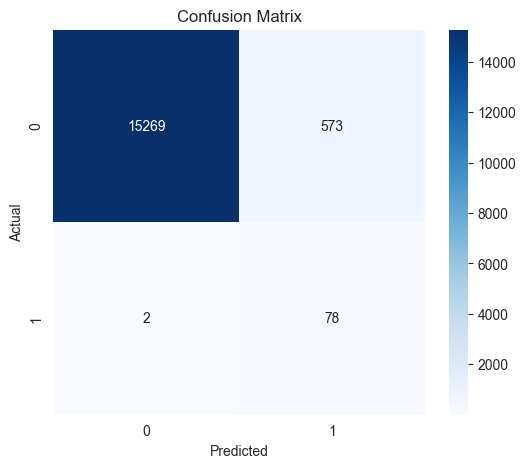

In [316]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# ROC AUC Score

In [317]:
roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.9808499558136599


# ROC Curve

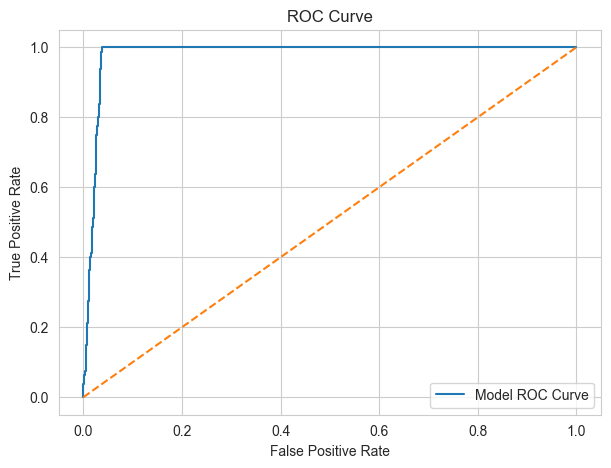

In [318]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="Model ROC Curve")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# Feature Importance

In [319]:
# Get all feature names properly
tfidf_features = tfidf_vectorizer.get_feature_names_out()
device_features = encoder.get_feature_names_out(["browser", "os", "locale"])
numerical_features = ["num_sites", "total_time", "avg_time", "hour", "weekday"]

# Combine all feature names in the same order as X_final
all_feature_names = np.concatenate([
    tfidf_features,
    device_features,
    numerical_features
])

# Now create importance dataframe with matching dimensions
coefficients = model.coef_[0]

importance = pd.DataFrame({
    "feature": all_feature_names,
    "weight": coefficients
})

top_features = importance.sort_values("weight", ascending=False).head(20)
top_features

,feature,weight
5028,locale_ru_RU,8.796091
4056,slack,5.677746
611,boitedependore,4.001622
399,asosservices,3.523739
4729,vk,3.463385
4337,temple,3.378609
585,blog,3.161954
102,abc,3.132732
881,cinejaude,3.066154
4024,silicon,2.998625


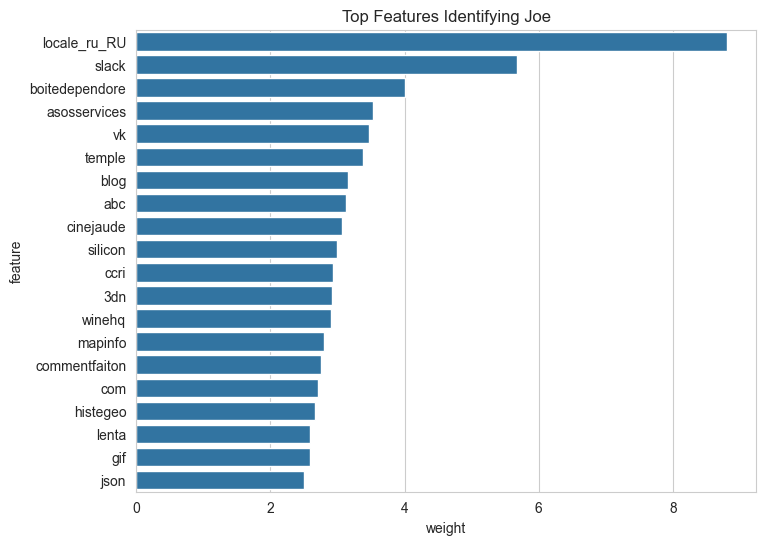

In [320]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="weight",
    y="feature",
    data=top_features
)

plt.title("Top Features Identifying Joe")

plt.show()

# Cross Validation

In [321]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Cross Validation Scores:", scores)

print("Average ROC-AUC:", scores.mean())

/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/ssingodia/Desktop/Catching_Joe/joe_env/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/ssingodi

Cross Validation Scores: [0.98225805 0.98327399 0.98090428 0.98163665 0.98306439]
Average ROC-AUC: 0.9822274717904206


# Error Analysis

In [322]:
errors = X_test[((y_test == 1) & (y_pred == 0)).values]

print("Missed Joe Sessions:", errors.shape[0])

Missed Joe Sessions: 2


# Phase 5

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     15842
           1       0.12      0.97      0.21        80

    accuracy                           0.96     15922
   macro avg       0.56      0.97      0.60     15922
weighted avg       1.00      0.96      0.98     15922

